In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from PIL import Image

In [2]:
metadata_path = "HAM10000_metadata.csv"
df = pd.read_csv(metadata_path)

In [3]:
print("Shape of dataset:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nMissing values:\n", df.isnull().sum())
print("\nClass distribution:\n", df['dx'].value_counts())

Shape of dataset: (10015, 7)

Columns: ['lesion_id', 'image_id', 'dx', 'dx_type', 'age', 'sex', 'localization']

Missing values:
 lesion_id        0
image_id         0
dx               0
dx_type          0
age             57
sex              0
localization     0
dtype: int64

Class distribution:
 dx
nv       6705
mel      1113
bkl      1099
bcc       514
akiec     327
vasc      142
df        115
Name: count, dtype: int64


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_18464\423861083.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='dx', order=df['dx'].value_counts().index, palette="Set2")


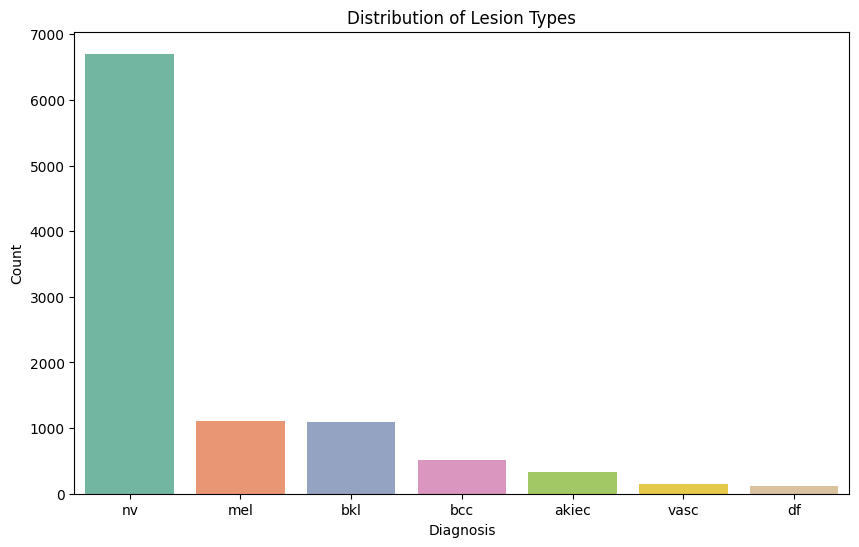

In [4]:
plt.figure(figsize=(10,6))
sns.countplot(data=df, x='dx', order=df['dx'].value_counts().index, palette="Set2")
plt.title("Distribution of Lesion Types")
plt.xlabel("Diagnosis")
plt.ylabel("Count")
plt.show()

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_18464\3975316904.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='sex', palette="pastel")


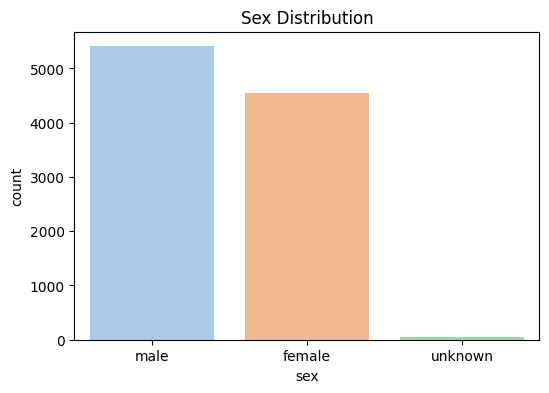

In [5]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='sex', palette="pastel")
plt.title("Sex Distribution")
plt.show()

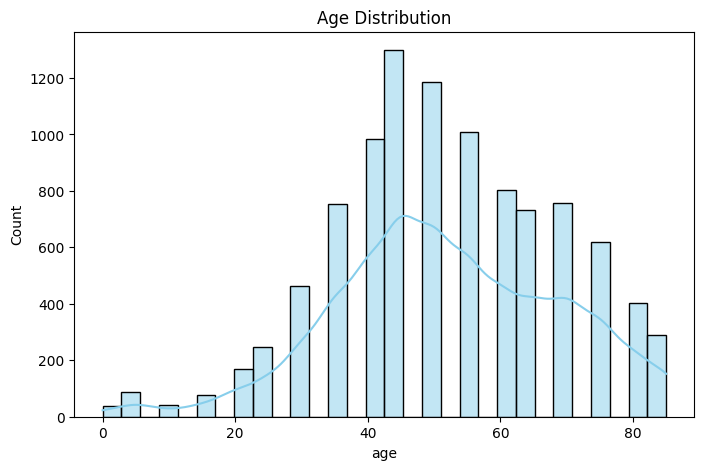

In [6]:
plt.figure(figsize=(8,5))
sns.histplot(data=df, x='age', bins=30, kde=True, color='skyblue')
plt.title("Age Distribution")
plt.show()

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_18464\3230026462.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='dx', y='age', palette="Set3")


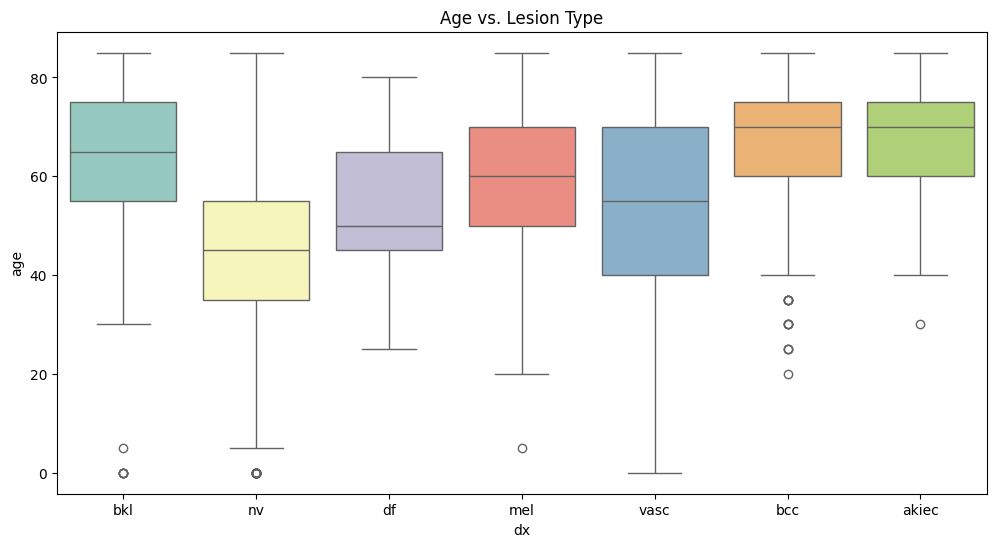

In [7]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df, x='dx', y='age', palette="Set3")
plt.title("Age vs. Lesion Type")
plt.show()

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_18464\3655927740.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y='localization', order=df['localization'].value_counts().index, palette="viridis")


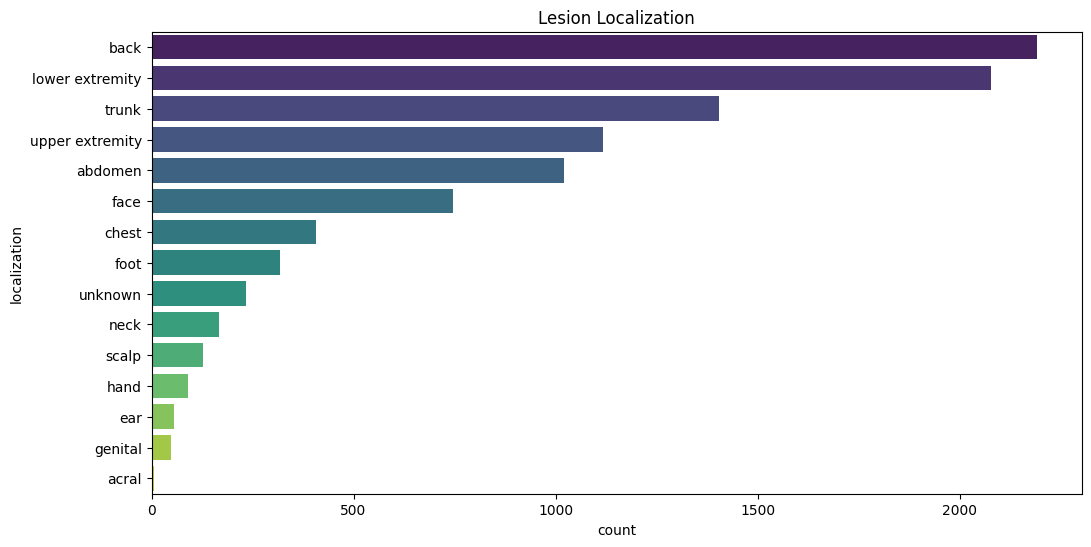

In [8]:
plt.figure(figsize=(12,6))
sns.countplot(data=df, y='localization', order=df['localization'].value_counts().index, palette="viridis")
plt.title("Lesion Localization")
plt.show()

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_18464\2959953989.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='dx_type', palette="coolwarm")


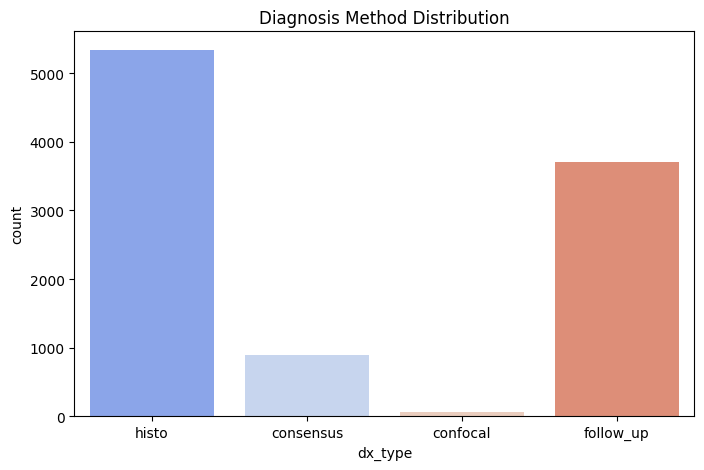

In [9]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='dx_type', palette="coolwarm")
plt.title("Diagnosis Method Distribution")
plt.show()

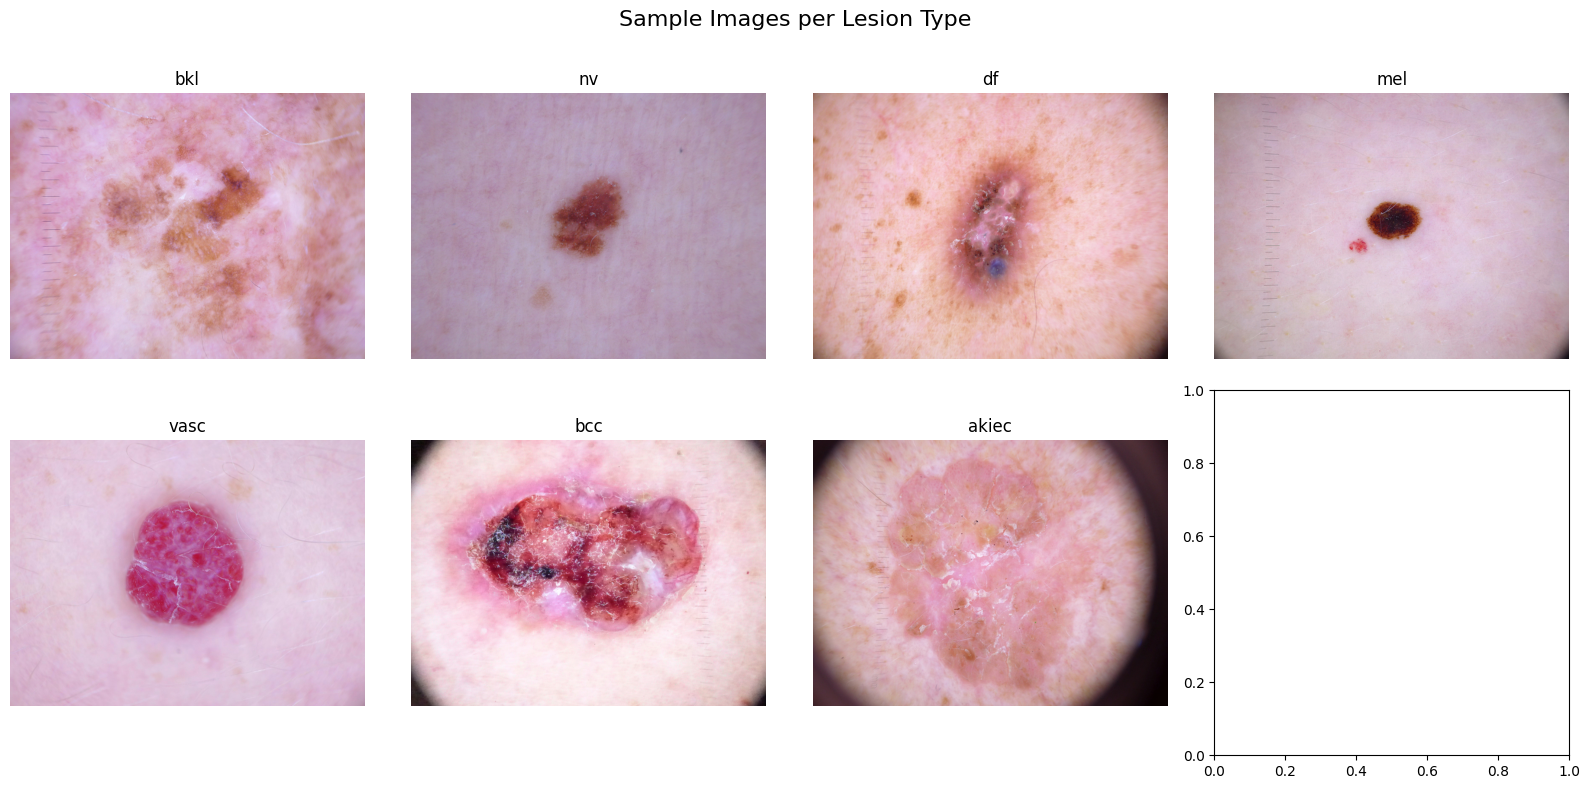

In [10]:
data_dir = "./archive/"
part1 = os.path.join(data_dir, "HAM10000_images_part_1")
part2 = os.path.join(data_dir, "HAM10000_images_part_2")

image_paths = {}
for folder in [part1, part2]:
    for fname in os.listdir(folder):
        if fname.endswith(".jpg"):
            image_id = fname.replace(".jpg", "")
            image_paths[image_id] = os.path.join(folder, fname)

fig, axes = plt.subplots(2,4, figsize=(16,8))
classes = df['dx'].unique()

for i, lesion in enumerate(classes[:8]):
    sample_id = df[df['dx']==lesion]['image_id'].iloc[0]
    img_path = image_paths.get(sample_id, None)
    if img_path and os.path.exists(img_path):
        img = Image.open(img_path)
        axes[i//4, i%4].imshow(img)
        axes[i//4, i%4].set_title(lesion)
        axes[i//4, i%4].axis("off")

plt.suptitle("Sample Images per Lesion Type", fontsize=16)
plt.tight_layout()
plt.show()

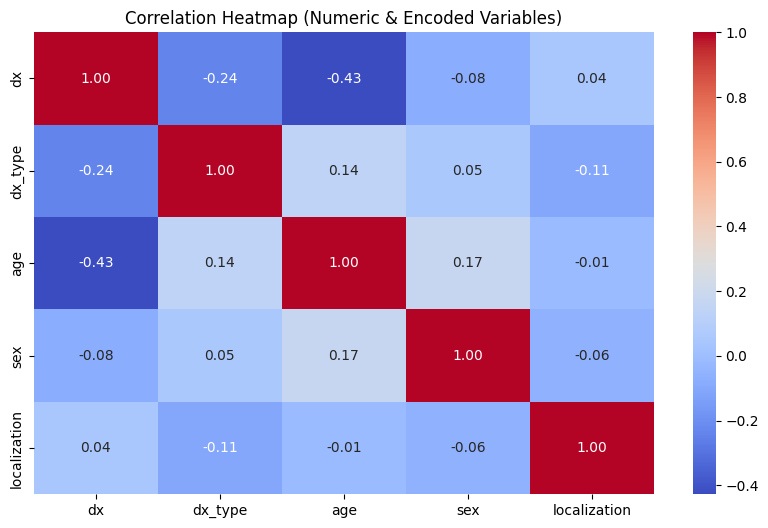

In [13]:
df_encoded = df.copy()
df_encoded['sex'] = df_encoded['sex'].map({'male': 1, 'female': 0})
df_encoded['dx'] = df_encoded['dx'].astype('category').cat.codes
df_encoded['localization'] = df_encoded['localization'].astype('category').cat.codes
df_encoded['dx_type'] = df_encoded['dx_type'].astype('category').cat.codes

# Select only numeric columns
numeric_df = df_encoded.select_dtypes(include=[np.number])

plt.figure(figsize=(10,6))
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap (Numeric & Encoded Variables)")
plt.show()

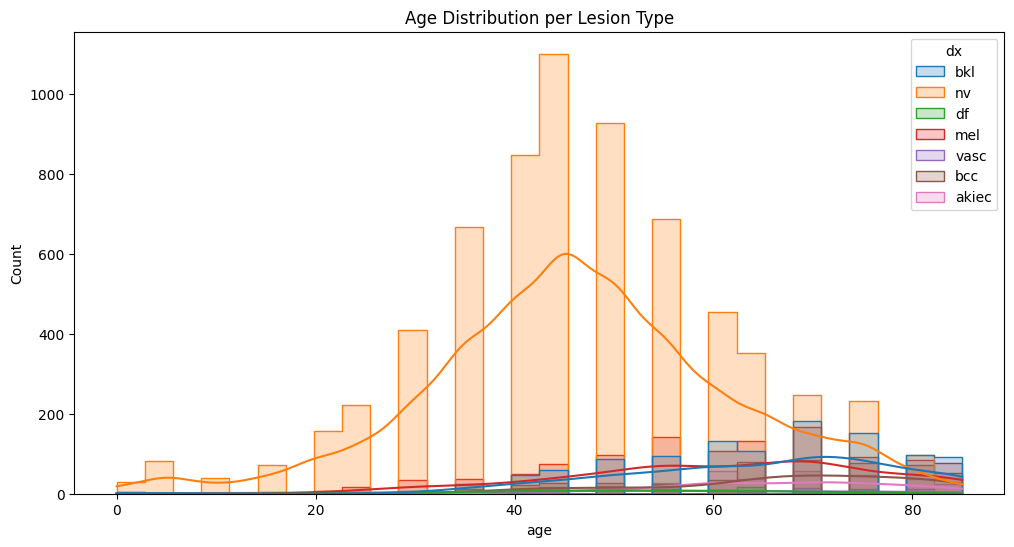

In [14]:
plt.figure(figsize=(12,6))
sns.histplot(data=df, x='age', hue='dx', bins=30, kde=True, element='step')
plt.title("Age Distribution per Lesion Type")
plt.show()

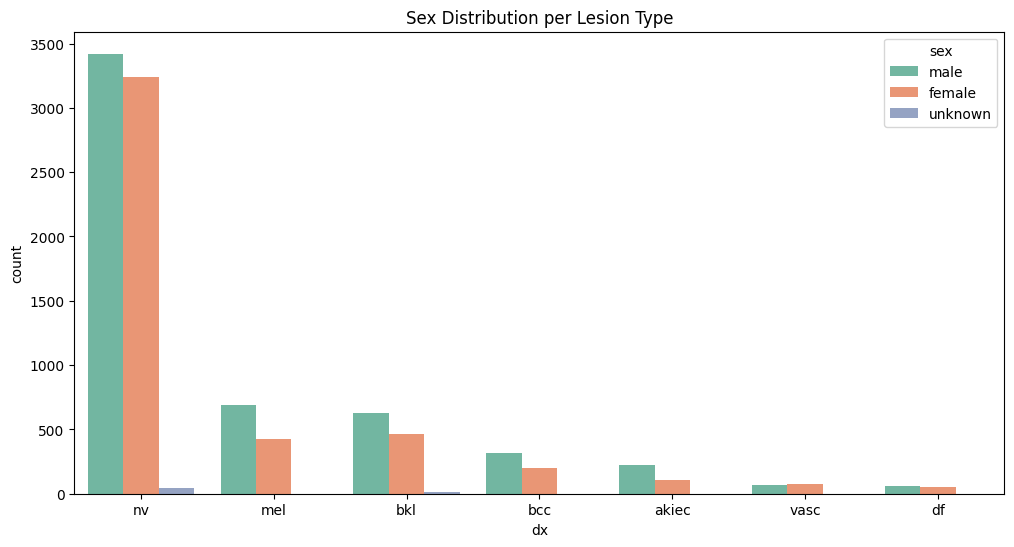

In [15]:
plt.figure(figsize=(12,6))
sns.countplot(data=df, x='dx', hue='sex', order=df['dx'].value_counts().index, palette="Set2")
plt.title("Sex Distribution per Lesion Type")
plt.show()